# Compare models


## Load results from models
Format : liste [num de frame, x_centroïde, y_centroïde, confiance]

### YOLO

In [1]:
import cv2
from ultralytics import YOLO

def extraire_centroid_balle_bbox(model_path, target_class, video_path, frame_step=1):
    # 1. Chargement du modèle
    model = YOLO(model_path)
    
    # Identification de l'ID de la classe
    class_ids = {v: k for k, v in model.names.items()}
    if target_class not in class_ids:
        print(f"Classe '{target_class}' introuvable.")
        return []
    target_id = class_ids[target_class]

    cap = cv2.VideoCapture(video_path)
    resultats_centroids = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_step == 0:
            # Inférence
            results = model(frame, verbose=False)[0]
            
            # On parcourt les boîtes détectées
            for box in results.boxes:
                cls_id = int(box.cls[0])
                if cls_id == target_id:
                    # On peut utiliser .xywh qui donne directement le centre (x, y)
                    # format : [x_centre, y_centre, largeur, hauteur]
                    x_c, y_c, w, h = box.xywh[0].tolist()
                    
                    conf = float(box.conf[0])
                    
                    # On stocke : [Frame, Centroïde_X, Centroïde_Y, Confiance]
                    resultats_centroids.append([frame_idx, int(x_c), int(y_c), conf])

        frame_idx += 1

    cap.release()
    return resultats_centroids



In [2]:
yolo_immobile = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_immobile/video_immobile.mp4", frame_step=10)
for res in yolo_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Frame 0 : X=341, Y=361, Conf=0.9754864573478699
Frame 10 : X=341, Y=361, Conf=0.9715079665184021
Frame 20 : X=341, Y=361, Conf=0.9711005091667175
Frame 30 : X=341, Y=361, Conf=0.9737160801887512
Frame 40 : X=341, Y=361, Conf=0.9732313752174377
Frame 50 : X=341, Y=361, Conf=0.9730944037437439
Frame 60 : X=341, Y=361, Conf=0.9750104546546936
Frame 70 : X=341, Y=361, Conf=0.9751787781715393
Frame 80 : X=341, Y=361, Conf=0.9749793410301208
Frame 90 : X=341, Y=361, Conf=0.975992739200592


In [3]:
yolo_lent = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_lente/video_lente.mp4", frame_step=5)

In [4]:
yolo_simple = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_simple/video_simple.mp4", frame_step=5)

### CV2

In [5]:
import cv2
import numpy as np
from utils.tracking_utils_2D import BallTracker, PlayerDetector, TablePnPEstimator, PingPongUmpire, CourtVisualizer

clicked_points = []

def mouse_callback(event, x, y, flags, param):
    global clicked_points
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))

def main(video_path):
    global clicked_points
    # --- 1. INITIALISATION DE LA LISTE ---
    ball_positions = [] 
    
    VIDEO_PATH = video_path
    WINDOW_MAIN = "Smart Tracker (Video)"
    WINDOW_3D = "3D Court Radar"
    TARGET_WIDTH = 800
    LOOP_VIDEO = False # Mis à False pour que la fonction se termine et renvoie la liste

    cv2.namedWindow(WINDOW_MAIN, cv2.WINDOW_NORMAL)
    cv2.namedWindow(WINDOW_3D, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(WINDOW_MAIN, mouse_callback)

    ball_tracker = BallTracker(buffer_size=32, max_jump_dist=400, window_name=WINDOW_MAIN)
    ball_tracker.setup_trackbars()
    player_detector = PlayerDetector()
    umpire = PingPongUmpire()
    visualizer = CourtVisualizer(scale=0.15)

    stream = cv2.VideoCapture(VIDEO_PATH)
    if not stream.isOpened(): return []

    ret, initial_frame = stream.read()
    if not ret: return []
    
    height, width = initial_frame.shape[:2]

    pnp_estimator = TablePnPEstimator(frame_width=width, frame_height=height)
    
    while len(clicked_points) < 4:
        temp_frame = initial_frame.copy()
        for pt in clicked_points:
            cv2.circle(temp_frame, pt, 5, (0, 255, 255), -1)
        
        instruction = f"Click 4 corners: Net L, Near L, Near R, Net R ({len(clicked_points)}/4)"
        cv2.putText(temp_frame, instruction, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        cv2.imshow(WINDOW_MAIN, temp_frame)
        if cv2.waitKey(1) == ord('q'): return []

    pnp_estimator.update_camera_pose(clicked_points)
    stream.set(cv2.CAP_PROP_POS_FRAMES, 0)

    display_text = ""
    display_timer = 0

    print("Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.")

    while True:
        # --- 2. RÉCUPÉRER L'INDEX DE LA FRAME ---
        current_frame_idx = int(stream.get(cv2.CAP_PROP_POS_FRAMES))
        
        ret, frame = stream.read()
        if not ret:
            break # Fin de la vidéo, on sort de la boucle pour renvoyer la liste

        
        cv2.polylines(frame, [np.int32(clicked_points)], True, (0, 255, 0), 2)
        for pt in clicked_points:
            cv2.circle(frame, pt, 5, (0, 255, 255), -1)

        frame = player_detector.process(frame)
        frame, ball_center, ball_w = ball_tracker.process(frame)
        
        # --- 3. STOCKAGE DES COORDONNÉES ---
        # On enregistre même si ball_center est None (pour garder la synchro frame par frame)
        # ou seulement si détecté, selon ton besoin. Ici, on enregistre les détections :
        if ball_center is not None:
            conf = getattr(ball_tracker, 'last_confidence', 1.0)
            ball_positions.append([
                current_frame_idx, 
                round(ball_center[0], 2), 
                round(ball_center[1], 2), 
                round(conf, 2)
            ])
        
        current_table_coords = None
        if ball_center is not None and pnp_estimator.rvec is not None:
            bx, by = ball_center
            table_coords = pnp_estimator.project_ball_to_table_plane(bx, by)
            if table_coords:
                current_table_coords = table_coords
                wx, wy = table_coords
                bounce_result = umpire.update(by, wx, wy)
                if bounce_result:
                    display_text = bounce_result
                    display_timer = 45 

        minimap = visualizer.draw(table_coords=current_table_coords, text=display_text if display_timer > 0 else "")

        if display_timer > 0:
            color = (0, 255, 0) if "IN" in display_text else (0, 0, 255)
            cv2.putText(frame, display_text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4, cv2.LINE_AA)
            display_timer -= 1

        cv2.imshow(WINDOW_MAIN, frame)
        cv2.imshow(WINDOW_3D, minimap)

        if cv2.waitKey(1) == ord('q'): break

    stream.release()
    cv2.destroyAllWindows()
    
    return ball_positions


In [6]:
import cv2
from utils.tracking_utils import  BallTracker, PlayerDetector
def main1(video_path):
    """
    Analyse une vidéo et renvoie une liste de détections.
    Format : [[frame_idx, x, y, conf], ...]
    """
    WINDOW_NAME = "Smart Tracker (Analyse Video)"
    cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)

    # Initialisation des outils
    ball_tracker = BallTracker(buffer_size=32, max_jump_dist=200, window_name=WINDOW_NAME)
    ball_tracker.setup_trackbars()
    player_detector = PlayerDetector()

    # Chargement de la source
    stream = cv2.VideoCapture(video_path)
    
    trajectory_results = []
    frame_idx = 0

    while True:
        ret, frame = stream.read()
        if not ret or frame is None:
            break

        frame_idx += 1
        
        # On ne flip pas l'image pour un fichier vidéo (contrairement à une webcam)
        # frame = cv2.flip(frame, 1) 

        # Traitement (on stocke le retour pour éviter les erreurs d'affichage)
        img_player = player_detector.process(frame)
        if img_player is not None: frame = img_player
        
        img_ball = ball_tracker.process(frame)
        if img_ball is not None: frame = img_ball

        # --- EXTRACTION DES DONNÉES ---
        # Note : On suppose que ball_tracker possède un attribut last_detection mis à jour dans process()
        # Si ta classe utilise des noms différents (ex: self.center), adapte les lignes ci-dessous.
        if hasattr(ball_tracker, 'last_detection') and ball_tracker.last_detection is not None:
            x, y, conf = ball_tracker.last_detection
            # Format demandé : [num de frame, x_centroïde, y_centroïde, confiance]
            trajectory_results.append([frame_idx, int(x), int(y), round(float(conf), 2)])

    
    return trajectory_results




In [8]:
CV2_ball_immobile = main("roboflow/dataset_labelise/video_immobile/video_immobile.mp4")
for res in CV2_ball_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


I0000 00:00:1773854834.580533  496983 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1773854834.708582  498231 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773854834.721993  498235 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


ValueError: too many values to unpack (expected 3)

In [ ]:
CV2_ball_lente = main("roboflow/dataset_labelise/video_lente/video_lente.mp4")
for res in CV2_ball_lente[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


I0000 00:00:1773854745.586975  462593 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1773854745.697728  495463 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773854745.713506  495463 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


ValueError: too many values to unpack (expected 3)

In [ ]:
CV2_ball_simple = main("roboflow/dataset_labelise/video_simple/video_simple.mp4")
#for res in CV2_ball_lente[:10]:
   #print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


I0000 00:00:1773248842.241148  100482 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1773248842.349427  115531 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773248842.366714  115531 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Basic CV2


In [ ]:
import cv2
import numpy as np

def extraire_coords_hsv(video_name, video_path, frame_step=1):
    """
    Détecte la balle par couleur HSV et renvoie les centroïdes.
    Sortie : Liste de [num_frame, x_centroïde, y_centroïde, confiance]
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Erreur : Impossible d'ouvrir la vidéo {video_path}")
        return []

    # --- Configuration HSV (Balle jaune/orange selon votre code) ---
    lower_color = np.array([5, 150, 150])
    upper_color = np.array([15, 255, 255])

    resultats = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Traitement selon le pas (frame_step)
        if frame_idx % frame_step == 0:
            # 1. Conversion et Masquage
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv, lower_color, upper_color)

            # 2. Nettoyage du bruit
            mask = cv2.medianBlur(mask, 5)
            mask = cv2.dilate(mask, None, iterations=2)

            # 3. Détection des contours
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if area > 50:  # Filtre de taille minimum
                    # 4. Calcul du centroïde via le cercle englobant
                    (x, y), radius = cv2.minEnclosingCircle(cnt)
                    
                    # On stocke les coordonnées
                    # Note : La confiance est mise à 1.0 car c'est une détection binaire
                    resultats.append([frame_idx, int(x), int(y), 1.0])
                    
                    # On s'arrête au premier contour trouvé pour éviter les faux positifs 
                    # (si on suppose qu'il n'y a qu'une seule balle)
                    break 

        frame_idx += 1

    cap.release()
    return resultats


In [ ]:

basic_immobile_ball = extraire_coords_hsv("video_immobile", "roboflow/dataset_labelise/video_immobile/video_immobile.mp4", frame_step=15)
print("Exemple de résultats (frame, x, y, conf) :")
for res in basic_immobile_ball[:10]:
    print(res)

Exemple de résultats (frame, x, y, conf) :
[0, 341, 369, 1.0]
[15, 341, 369, 1.0]
[30, 340, 368, 1.0]
[45, 340, 368, 1.0]
[60, 340, 369, 1.0]
[75, 340, 369, 1.0]
[90, 340, 369, 1.0]
[105, 340, 369, 1.0]
[120, 339, 370, 1.0]
[135, 339, 370, 1.0]


In [ ]:

basic_lente_ball = extraire_coords_hsv("video_lente", "roboflow/dataset_labelise/video_lente/video_lente.mp4", frame_step=15)
print("Exemple de résultats (frame, x, y, conf) :")
for res in basic_lente_ball[:10]:
    print(res)

Exemple de résultats (frame, x, y, conf) :
[15, 604, 234, 1.0]
[30, 547, 323, 1.0]
[45, 545, 392, 1.0]
[60, 571, 430, 1.0]
[75, 569, 428, 1.0]
[90, 476, 194, 1.0]
[105, 442, 299, 1.0]
[120, 447, 410, 1.0]
[135, 455, 406, 1.0]
[150, 472, 404, 1.0]


In [ ]:

basic_simple_ball = extraire_coords_hsv("video_simple", "roboflow/dataset_labelise/video_simple/video_simple.mp4", frame_step=15)
print("Exemple de résultats (frame, x, y, conf) :")
for res in basic_simple_ball[:10]:
    print(res)

Exemple de résultats (frame, x, y, conf) :
[60, 322, 305, 1.0]
[90, 320, 297, 1.0]


## Comparaison avec le fichier labellisé

In [ ]:
import pandas as pd
import numpy as np

def calculer_distances_eucl(video_nom_cible, results, csv_path):
    
    # 1. Chargement du CSV avec gestion du header
    df_gt = pd.read_csv(csv_path)
    
    # On récupère le nom des colonnes pour être flexible
    # Supposons : col 0 = video, col 1 = frame, col 2-5 = x1, y1, x2, y2
    cols = df_gt.columns
    col_video = cols[0]
    col_frame = cols[1]
    
    # 2. Filtrage strict sur le nom de la vidéo
    df_video = df_gt[df_gt[col_video] == video_nom_cible].copy()
    
    if df_video.empty:
        print(f"Attention : Aucune donnée trouvée pour la vidéo '{video_nom_cible}'")
        return []

    # 3. Calcul des centroïdes Ground Truth (GT)
    # Formule : (x1 + x2) / 2
    df_video['cx_gt'] = (df_video[cols[2]] + df_video[cols[4]]) / 2
    df_video['cy_gt'] = (df_video[cols[3]] + df_video[cols[5]]) / 2
    
    # Création d'un dictionnaire pour mapper {frame_id: (cx, cy)}
    gt_map = df_video.set_index(col_frame)[['cx_gt', 'cy_gt']].to_dict('index')
    print(gt_map)  # Affiche les premiers frame_id pour vérification
    distances_finales = []

    # 4. Comparaison avec les résultats 
    for res in results:
        f_idx, cx, cy, _ = res
        
        # On vérifie si le numéro de frame existe dans le CSV filtré
        if f_idx in gt_map:
            gt_cx = gt_map[f_idx]['cx_gt']
            gt_cy = gt_map[f_idx]['cy_gt']
            
            # Calcul de la distance euclidienne
            dist = np.sqrt((cx - gt_cx)**2 + (cy - gt_cy)**2)
            distances_finales.append(dist)
        else:
            # Optionnel : log si une frame analysée n'est pas labellisée
            pass

    return distances_finales

In [ ]:
error_yolo_immobile = calculer_distances_eucl("video_immobile", yolo_immobile, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': 341.405, 'cy_gt': 361.21000000000004}, 15: {'cx_gt': 341.405, 'cy_gt': 361.605}, 30: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 45: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 60: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 75: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 90: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 105: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 120: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 135: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 150: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 165: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 180: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 195: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 210: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 225: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 240: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}}


In [ ]:
error_yolo_lente = calculer_distances_eucl("video_lente", yolo_lent, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 15: {'cx_gt': 603.975, 'cy_gt': 234.42000000000002}, 30: {'cx_gt': 546.77, 'cy_gt': 322.46000000000004}, 45: {'cx_gt': 557.4300000000001, 'cy_gt': 409.38}, 60: {'cx_gt': 557.4300000000001, 'cy_gt': 428.45}, 75: {'cx_gt': 557.4300000000001, 'cy_gt': 424.525}, 90: {'cx_gt': 477.24, 'cy_gt': 193.48000000000002}, 105: {'cx_gt': 441.35, 'cy_gt': 295.53999999999996}, 120: {'cx_gt': 457.04999999999995, 'cy_gt': 421.15999999999997}, 135: {'cx_gt': 460.40999999999997, 'cy_gt': 427.89}, 150: {'cx_gt': 462.1, 'cy_gt': 427.89}, 165: {'cx_gt': 459.85, 'cy_gt': 420.03999999999996}, 180: {'cx_gt': 268.065, 'cy_gt': 196.845}, 195: {'cx_gt': 199.085, 'cy_gt': 215.355}, 210: {'cx_gt': 171.61, 'cy_gt': 349.935}, 225: {'cx_gt': 181.135, 'cy_gt': 412.75}, 240: {'cx_gt': 183.89499999999998, 'cy_gt': 410.97}, 255: {'cx_gt': 185.82999999999998, 'cy_gt': 345.395}, 270: {'cx_gt': 243.235, 'cy_gt': 204.57999999999998}, 285: {'cx_gt': 443.82, 'cy_gt': 100.305}, 300: {'cx_gt': nan

In [ ]:
error_yolo_simple = calculer_distances_eucl("video_simple", yolo_simple, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 5: {'cx_gt': 219.1, 'cy_gt': 238.965}, 10: {'cx_gt': 201.055, 'cy_gt': 364.005}, 15: {'cx_gt': nan, 'cy_gt': nan}, 20: {'cx_gt': nan, 'cy_gt': nan}, 25: {'cx_gt': nan, 'cy_gt': nan}, 30: {'cx_gt': nan, 'cy_gt': nan}, 35: {'cx_gt': nan, 'cy_gt': nan}, 40: {'cx_gt': nan, 'cy_gt': nan}, 45: {'cx_gt': nan, 'cy_gt': nan}, 50: {'cx_gt': nan, 'cy_gt': nan}, 55: {'cx_gt': 352.06, 'cy_gt': 204.26999999999998}, 60: {'cx_gt': 327.405, 'cy_gt': 296.865}, 65: {'cx_gt': 325.0, 'cy_gt': 232.53}, 70: {'cx_gt': 347.85, 'cy_gt': 167.89499999999998}, 75: {'cx_gt': 467.885, 'cy_gt': 11.085}, 80: {'cx_gt': nan, 'cy_gt': nan}, 85: {'cx_gt': nan, 'cy_gt': nan}, 90: {'cx_gt': nan, 'cy_gt': nan}, 95: {'cx_gt': nan, 'cy_gt': nan}, 100: {'cx_gt': nan, 'cy_gt': nan}, 105: {'cx_gt': 75.765, 'cy_gt': 16.755000000000003}, 110: {'cx_gt': 76.095, 'cy_gt': 308.66}, 115: {'cx_gt': 94.72, 'cy_gt': 301.125}, 120: {'cx_gt': 67.015, 'cy_gt': 214.98000000000002}, 125: {'cx_gt': nan, 'cy_gt':

In [ ]:
error_CV2_immobile = calculer_distances_eucl("video_immobile", CV2_ball_immobile, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': 341.405, 'cy_gt': 361.21000000000004}, 15: {'cx_gt': 341.405, 'cy_gt': 361.605}, 30: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 45: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 60: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 75: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 90: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 105: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 120: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 135: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 150: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 165: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 180: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 195: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 210: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 225: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 240: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}}


In [ ]:
error_CV2_lente=calculer_distances_eucl("video_lente", CV2_ball_lente, "roboflow/dataset_labelise/annotations.csv")
print(len(error_CV2_lente), len(error_yolo_lente))

{0: {'cx_gt': nan, 'cy_gt': nan}, 15: {'cx_gt': 603.975, 'cy_gt': 234.42000000000002}, 30: {'cx_gt': 546.77, 'cy_gt': 322.46000000000004}, 45: {'cx_gt': 557.4300000000001, 'cy_gt': 409.38}, 60: {'cx_gt': 557.4300000000001, 'cy_gt': 428.45}, 75: {'cx_gt': 557.4300000000001, 'cy_gt': 424.525}, 90: {'cx_gt': 477.24, 'cy_gt': 193.48000000000002}, 105: {'cx_gt': 441.35, 'cy_gt': 295.53999999999996}, 120: {'cx_gt': 457.04999999999995, 'cy_gt': 421.15999999999997}, 135: {'cx_gt': 460.40999999999997, 'cy_gt': 427.89}, 150: {'cx_gt': 462.1, 'cy_gt': 427.89}, 165: {'cx_gt': 459.85, 'cy_gt': 420.03999999999996}, 180: {'cx_gt': 268.065, 'cy_gt': 196.845}, 195: {'cx_gt': 199.085, 'cy_gt': 215.355}, 210: {'cx_gt': 171.61, 'cy_gt': 349.935}, 225: {'cx_gt': 181.135, 'cy_gt': 412.75}, 240: {'cx_gt': 183.89499999999998, 'cy_gt': 410.97}, 255: {'cx_gt': 185.82999999999998, 'cy_gt': 345.395}, 270: {'cx_gt': 243.235, 'cy_gt': 204.57999999999998}, 285: {'cx_gt': 443.82, 'cy_gt': 100.305}, 300: {'cx_gt': nan

In [ ]:
error_CV2_simple=calculer_distances_eucl("video_simple", CV2_ball_simple, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 5: {'cx_gt': 219.1, 'cy_gt': 238.965}, 10: {'cx_gt': 201.055, 'cy_gt': 364.005}, 15: {'cx_gt': nan, 'cy_gt': nan}, 20: {'cx_gt': nan, 'cy_gt': nan}, 25: {'cx_gt': nan, 'cy_gt': nan}, 30: {'cx_gt': nan, 'cy_gt': nan}, 35: {'cx_gt': nan, 'cy_gt': nan}, 40: {'cx_gt': nan, 'cy_gt': nan}, 45: {'cx_gt': nan, 'cy_gt': nan}, 50: {'cx_gt': nan, 'cy_gt': nan}, 55: {'cx_gt': 352.06, 'cy_gt': 204.26999999999998}, 60: {'cx_gt': 327.405, 'cy_gt': 296.865}, 65: {'cx_gt': 325.0, 'cy_gt': 232.53}, 70: {'cx_gt': 347.85, 'cy_gt': 167.89499999999998}, 75: {'cx_gt': 467.885, 'cy_gt': 11.085}, 80: {'cx_gt': nan, 'cy_gt': nan}, 85: {'cx_gt': nan, 'cy_gt': nan}, 90: {'cx_gt': nan, 'cy_gt': nan}, 95: {'cx_gt': nan, 'cy_gt': nan}, 100: {'cx_gt': nan, 'cy_gt': nan}, 105: {'cx_gt': 75.765, 'cy_gt': 16.755000000000003}, 110: {'cx_gt': 76.095, 'cy_gt': 308.66}, 115: {'cx_gt': 94.72, 'cy_gt': 301.125}, 120: {'cx_gt': 67.015, 'cy_gt': 214.98000000000002}, 125: {'cx_gt': nan, 'cy_gt':

In [ ]:
error_basic_immobile=calculer_distances_eucl("video_immobile", basic_immobile_ball, "roboflow/dataset_labelise/annotations.csv")
error_basic_lente=calculer_distances_eucl("video_lente", basic_lente_ball, "roboflow/dataset_labelise/annotations.csv")
error_basic_simple=calculer_distances_eucl("video_simple", basic_simple_ball, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': 341.405, 'cy_gt': 361.21000000000004}, 15: {'cx_gt': 341.405, 'cy_gt': 361.605}, 30: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 45: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 60: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 75: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 90: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 105: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 120: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 135: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 150: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 165: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 180: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 195: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 210: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 225: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 240: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}}
{0: {'cx_gt': nan, 'cy_gt': nan}, 15: {'cx_gt': 603.975, 'cy_gt': 234.42000000000002}, 30: {'cx_gt':

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_comparison(frames, errors_yolo, errors_manual, error_basic, method='log'):
    plt.figure(figsize=(12, 6))
    
    # Conversion en arrays numpy pour faciliter les calculs
    ey = np.array(errors_yolo)
    em = np.array(errors_manual)
    eb = np.array(error_basic)

    if method == 'minmax':
        # Normalisation entre 0 et 1
        ey = (ey - ey.min()) / (ey.max() - ey.min())
        em = (em - em.min()) / (em.max() - em.min())
        eb = (eb - eb.min()) / (eb.max() - eb.min())
        plt.ylabel("Erreur Normalisée [0, 1]")
        
    elif method == 'log':
        # Utilisation d'une échelle logarithmique (Idéal pour les pics)
        plt.yscale('log')
        plt.ylabel("Erreur L2 (Échelle Log)")
        
    elif method == 'clip':
        # On plafonne l'erreur à un seuil max (ex: 100 pixels) pour ne pas écraser le graphe
        threshold = 100 
        ey = np.clip(ey, 0, threshold)
        em = np.clip(em, 0, threshold)
        eb = np.clip(eb, 0, threshold)
        plt.ylabel(f"Erreur L2 (Plafonnée à {threshold}px)")

    # Tracé des courbes
    plt.plot(frames, ey, label='Erreur YOLO', color='blue', alpha=0.8, linewidth=1.5)
    plt.plot(frames, em, label='Erreur BallTracker', color='red', alpha=0.8, linewidth=1.5)
    plt.plot(frames, eb, label='Erreur Tracker Basique', color='green', alpha=0.6, linestyle='--')

    plt.title(f"Comparaison de la précision des Trackers (Méthode: {method})")
    plt.xlabel("Numéro de la Frame")
    plt.legend()
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    plt.show()

# Exemple d'appel :
# plot_error_comparison(frames, err_y, err_m, err_b, method='log')

In [ ]:
plot_error_comparison(list(range(len(error_yolo_immobile))), error_yolo_immobile, error_CV2_immobile[:len(error_yolo_immobile)], error_basic_immobile[:len(error_yolo_immobile)] )

NameError: name 'error_yolo_immobile' is not defined

In [ ]:
print(len(error_yolo_immobile), len(error_CV2_immobile), len(error_basic_immobile))

9 17 17


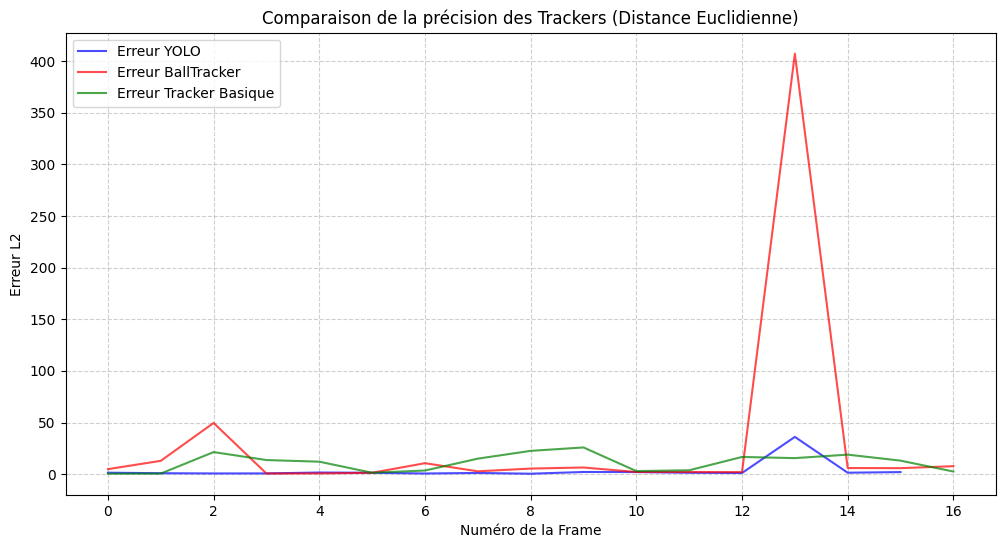

In [ ]:
plot_error_comparison(list(range(len(error_yolo_lente))), error_yolo_lente, error_CV2_lente[:len(error_yolo_lente)], error_basic_lente[:len(error_yolo_lente)])

ValueError: x and y must have same first dimension, but have shapes (9,) and (2,)

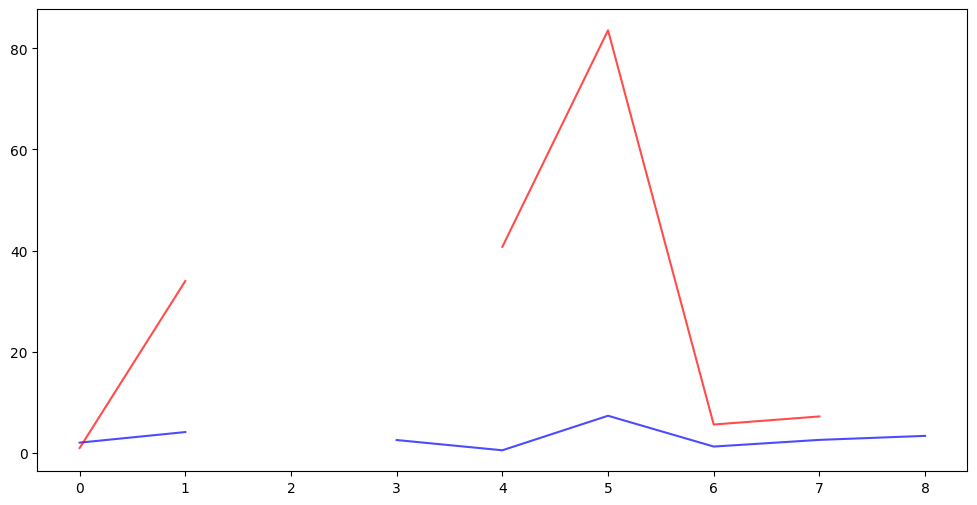

In [ ]:
plot_error_comparison(list(range(len(error_yolo_simple))), error_yolo_simple, error_CV2_simple[:len(error_yolo_simple)], error_basic_simple[:len(error_yolo_simple)])

In [ ]:
print(len(error_yolo_lente), len(error_CV2_lente), len(error_basic_lente))

17 22 20
